# Creating Synthetic data

In [10]:
import pandas as pd

data = {
    "review": [
        "I love this product",
        "This is the worst experience",
        "Absolutely fantastic service",
        "I hate it",
        "Not bad, could be better",
        "Very happy with the quality"
    ],
    "sentiment": [1, 0, 1, 0, 1, 1]  # 1 = Positive, 0 = Negative
}

df = pd.DataFrame(data)
df

,review,sentiment
0,I love this product,1
1,This is the worst experience,0
2,Absolutely fantastic service,1
3,I hate it,0
4,"Not bad, could be better",1
5,Very happy with the quality,1


# preprocessing & removing StopWords

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
type(ENGLISH_STOP_WORDS) ,len(ENGLISH_STOP_WORDS), len(set(ENGLISH_STOP_WORDS))

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = ENGLISH_STOP_WORDS # set(ENGLISH_STOP_WORDS)

text = "This is a simple example to show how to remove stopwords"
words = text.lower().split()

filtered_words = [w for w in words if w not in stop_words]

print("Original :", words)
print("Filtered :", filtered_words)

In [23]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

stop_words = set(ENGLISH_STOP_WORDS)
# stop_words = stop_words - {"not", "no", "never"}

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)
df

,review,sentiment,clean_review
0,I love this product,1,love product
1,This is the worst experience,0,worst experience
2,Absolutely fantastic service,1,absolutely fantastic service
3,I hate it,0,hate
4,"Not bad, could be better",1,bad better
5,Very happy with the quality,1,happy quality


# Normalization: Stemmer & Lemmitization

## Stemmer

In [13]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

words = ["running", "played", "studies", "happiness", "better"]
for w in words:
    print(w, "→", stemmer.stem(w))

running → run
played → play
studies → studi
happiness → happi
better → better


## Lemmitization

In [32]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
words = ["running", "better", "studies", "was"]
lemmas = [
    lemmatizer.lemmatize("running", pos=wordnet.VERB),
    lemmatizer.lemmatize("better", pos=wordnet.ADJ),
    lemmatizer.lemmatize("studies", pos=wordnet.NOUN),
    lemmatizer.lemmatize("was", pos=wordnet.VERB)
]
print(lemmas)

['run', 'good', 'study', 'be']


## All

In [12]:
import pandas as pd
import re
import nltk

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Download resources (run once)
nltk.download('wordnet')
nltk.download('omw-1.4')

# tools
stop_words = set(ENGLISH_STOP_WORDS) - {"not", "no", "never"}
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text, use_stemming=False, use_lemmatization=True):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)

    words = text.split()
    
    # Remove stopwords
    words = [w for w in words if w not in stop_words]

    # Apply stemming
    if use_stemming:
        words = [stemmer.stem(w) for w in words]

    # Apply lemmatization
    if use_lemmatization:
        words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

# Apply
df["processed_stem"] = df["review"].apply(lambda x: preprocess_text(x, use_stemming=True, use_lemmatization=False))
df["processed_lemma"] = df["review"].apply(lambda x: preprocess_text(x, use_stemming=False, use_lemmatization=True))

df[["review", "processed_stem", "processed_lemma"]]



[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Fathalla\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Fathalla\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,review,processed_stem,processed_lemma
0,I love this product,love product,love product
1,This is the worst experience,worst experi,worst experience
2,Absolutely fantastic service,absolut fantast servic,absolutely fantastic service
3,I hate it,hate,hate
4,"Not bad, could be better",not bad better,not bad better
5,Very happy with the quality,happi qualiti,happy quality


# Vectorization - Feature Extraction

## BOW

In [35]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["clean_review"])

X = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
X

,absolutely,bad,better,experience,fantastic,happy,hate,love,product,quality,service,worst
0,0,0,0,0,0,0,0,1,1,0,0,0
1,0,0,0,1,0,0,0,0,0,0,0,1
2,1,0,0,0,1,0,0,0,0,0,1,0
3,0,0,0,0,0,0,1,0,0,0,0,0
4,0,1,1,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,1,0,0,0,1,0,0


## TF-IDF

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english'   # remove stopwords
)

X = vectorizer.fit_transform(df["review"])

# Convert to readable format
tfidf_df = pd.DataFrame(
                        X.toarray(),
                        columns=vectorizer.get_feature_names_out()
                    )

tfidf_df

,absolutely,bad,better,experience,fantastic,happy,hate,love,product,quality,service,worst
0,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.707107,0.707107,0.000000,0.00000,0.000000
1,0.00000,0.000000,0.000000,0.707107,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.707107
2,0.57735,0.000000,0.000000,0.000000,0.57735,0.000000,0.0,0.000000,0.000000,0.000000,0.57735,0.000000
3,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,1.0,0.000000,0.000000,0.000000,0.00000,0.000000
4,0.00000,0.707107,0.707107,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.000000
5,0.00000,0.000000,0.000000,0.000000,0.00000,0.707107,0.0,0.000000,0.000000,0.707107,0.00000,0.000000


# ML

## Training

In [22]:
from sklearn import linear_model, tree, neural_network

from sklearn.model_selection import train_test_split

y = df["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# model = linear_model.LogisticRegression()
# model = tree.DecisionTreeClassifier()
model = neural_network.MLPClassifier()

model.fit(X_train, y_train)

C:\Users\Fathalla\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier()

## Evaluation

In [ ]:
test_sentences = ["I really love it", 
                  "This is terrible",
                  "worst experience"]

test_clean = [clean_text(s) for s in test_sentences]
test_vector = vectorizer.transform(test_clean)

predictions = model.predict(test_vector)

for sent, pred in zip(test_sentences, predictions):
    print(f"{sent} → {'Positive' if pred == 1 else 'Negative'}")

# IMDB Dataset

In [3]:
df = pd.read_csv('IMDB-Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


# Others: Word Cloud

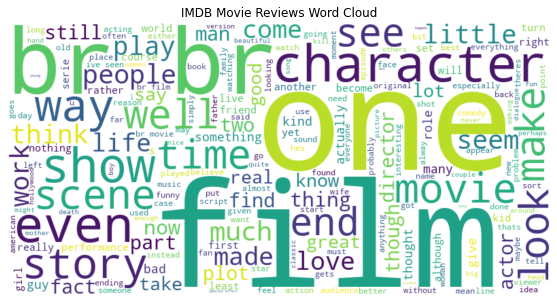

In [1]:
import pandas as pd
from wordcloud import STOPWORDS, WordCloud
import matplotlib.pyplot as plt
import re

df = pd.read_csv('IMDB Dataset.csv')

text = ' '.join(df['review'].astype(str).tolist())
text = re.sub(r'[^A-Za-z\s]', '', text)
text = text.lower()
stopwords = set(STOPWORDS)

text = ' '.join(word for word in text.split() if word not in stopwords)


wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("IMDB Movie Reviews Word Cloud")
plt.show()

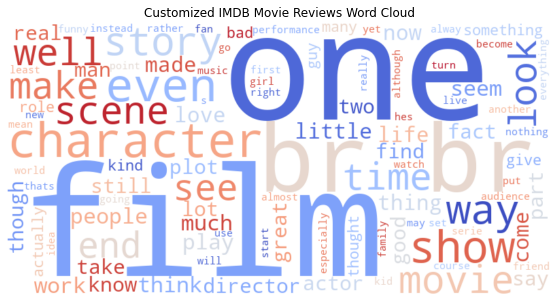

In [2]:
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='coolwarm').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Customized IMDB Movie Reviews Word Cloud")
plt.show()